# Notebook 02 - Feature Analysis
**Owner: Person B - Week 1**

Stage 2 Week 1 handoff: load cached activations, retrieve top-activating patches, and label inspected features with CLIP.

This notebook is orchestration only. Implementation lives in `src/cache.py`, `src/sae.py`, and `src/features.py`. Monosemanticity scores and report gallery figures remain Week 2 work.

## 0. Colab setup
Run this first in Colab. It clones the repo, optionally mounts Drive, and installs the project requirements.


In [7]:
from pathlib import Path
import os
import subprocess
import sys

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/kgunWf/Sparse-Feature-Circuits-in-ViTs.git"
REPO_DIR = Path("/content/Sparse-Feature-Circuits-in-ViTs")
MOUNT_GOOGLE_DRIVE = False
INSTALL_REQUIREMENTS = True

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
    if MOUNT_GOOGLE_DRIVE:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive")
    if INSTALL_REQUIREMENTS:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    print(f"Colab repo ready at {Path.cwd()}")
else:
    print("Local runtime detected; skipping Colab clone/install.")


Local runtime detected; skipping Colab clone/install.


## 1. Parameters
Start with these smoke-test values. On Colab, increase the counts after the cache and image paths resolve.

The repo clone does not include the activation cache or ImageNet images. Put them at the default paths inside the clone, or set `CACHE_PATH_OVERRIDE` and `IMAGE_ROOT_OVERRIDE` below.


In [8]:
CACHE_PATH_OVERRIDE = None  # e.g. "/content/drive/MyDrive/xai/activations.h5"
IMAGE_ROOT_OVERRIDE = None  # e.g. "/content/drive/MyDrive/xai/imagenet_val"

N_SMOKE_IMAGES = 8
FEATURE_IDX = 8736
TOP_K_PATCHES = 5

RUN_ALL_FEATURES_SMOKE = True
ALL_FEATURE_IMAGE_COUNT = 2
N_FEATURES_TO_INSPECT = 6

CONTEXT_PATCHES = 2
CROP_SIZE = 128
CLIP_TOP_N = 3


## 2. Load cache


In [9]:
from pathlib import Path
import sys

CACHE_PATH_OVERRIDE = globals().get("CACHE_PATH_OVERRIDE")
IMAGE_ROOT_OVERRIDE = globals().get("IMAGE_ROOT_OVERRIDE")

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
assert (repo_root / "src").exists(), f"Could not find repo root from {Path.cwd()}"
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.config import get_config
from src.cache import load_image_index, load_layer, load_metadata

def project_path(path):
    path = Path(path)
    return path if path.is_absolute() else repo_root / path

def image_path(path):
    path = Path(path)
    resolved = project_path(path)
    if resolved.exists() or IMAGE_ROOT_OVERRIDE is None:
        return resolved
    image_root = project_path(IMAGE_ROOT_OVERRIDE)
    by_name = image_root / path.name
    return by_name if by_name.exists() else image_root / path

cfg = get_config()
layer = cfg.sae.primary_layer
cache_path = project_path(CACHE_PATH_OVERRIDE or cfg.outputs.cache_path)

assert cache_path.exists(), f"Missing activation cache: {cache_path}"

metadata = load_metadata(cache_path)
index = load_image_index(cache_path)

assert layer in metadata["layers"], f"Layer {layer} not found in cache layers {metadata['layers']}"
assert len(index["paths"]) == metadata["n_images"]

print(f"Cache: {cache_path}")
print(f"Model: {metadata['model_name']}")
print(f"Layer: {layer}")
print(f"Images: {metadata['n_images']}")
print(f"First image: {index['paths'][0]}")


Cache: /Users/luffy/Desktop/XAI/Project/kev-slop/Sparse-Feature-Circuits-in-ViTs/outputs/caches/activations.h5
Model: facebook/dino-vitb16
Layer: 9
Images: 5000
First image: data/imagenet_val/img_0000.jpg


## 3. Load a local smoke-test slice


In [10]:
sample_indices = list(range(min(N_SMOKE_IMAGES, metadata["n_images"])))
sample_paths = [str(image_path(index["paths"][i])) for i in sample_indices]
missing_images = [path for path in sample_paths if not Path(path).exists()]
assert not missing_images, f"Missing image files. Set IMAGE_ROOT_OVERRIDE; first missing: {missing_images[0]}"

activations = load_layer(layer, indices=sample_indices, cachepath=cache_path)

print(f"Loaded activations: {tuple(activations.shape)}")


Loaded activations: (8, 197, 768)


## 4. Top patches - single feature


In [11]:
from src.features import get_top_patches

top_patches = get_top_patches(
    layer=layer,
    feature_idx=FEATURE_IDX,
    activations=activations,
    image_paths=sample_paths,
    k=TOP_K_PATCHES,
)

top_patches


[{'image_path': '/Users/luffy/Desktop/XAI/Project/kev-slop/Sparse-Feature-Circuits-in-ViTs/data/imagenet_val/img_0000.jpg',
  'image_idx': 0,
  'token_idx': 141,
  'activation_value': 9.018266677856445,
  'patch_row': 10,
  'patch_col': 0},
 {'image_path': '/Users/luffy/Desktop/XAI/Project/kev-slop/Sparse-Feature-Circuits-in-ViTs/data/imagenet_val/img_0000.jpg',
  'image_idx': 0,
  'token_idx': 155,
  'activation_value': 8.887055397033691,
  'patch_row': 11,
  'patch_col': 0},
 {'image_path': '/Users/luffy/Desktop/XAI/Project/kev-slop/Sparse-Feature-Circuits-in-ViTs/data/imagenet_val/img_0000.jpg',
  'image_idx': 0,
  'token_idx': 169,
  'activation_value': 8.847895622253418,
  'patch_row': 12,
  'patch_col': 0},
 {'image_path': '/Users/luffy/Desktop/XAI/Project/kev-slop/Sparse-Feature-Circuits-in-ViTs/data/imagenet_val/img_0000.jpg',
  'image_idx': 0,
  'token_idx': 98,
  'activation_value': 8.800697326660156,
  'patch_row': 6,
  'patch_col': 13},
 {'image_path': '/Users/luffy/Desktop

## 5. Visual sanity check - one feature


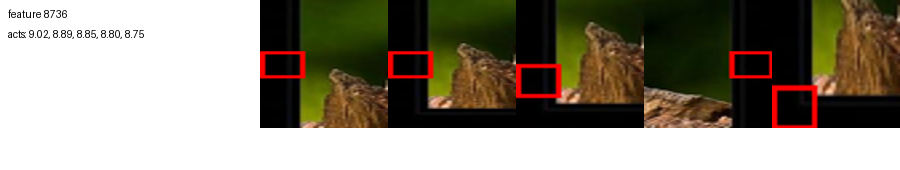

In [12]:
from PIL import Image, ImageDraw
from src.features import crop_patch_images


def make_patch_grid(feature_patches, labels=None, context_patches=CONTEXT_PATCHES, crop_size=CROP_SIZE, max_patches=None):
    labels = labels or {}
    max_patches = max_patches or TOP_K_PATCHES
    feature_items = list(feature_patches.items())
    if not feature_items:
        return Image.new("RGB", (320, 80), color="white")

    label_width = 260
    row_height = crop_size + 42
    width = label_width + max_patches * crop_size
    height = row_height * len(feature_items)
    grid = Image.new("RGB", (width, height), color="white")
    draw = ImageDraw.Draw(grid)

    for row, (feature_idx, patches) in enumerate(feature_items):
        y = row * row_height
        title = f"feature {feature_idx}"
        if feature_idx in labels:
            title += " | " + ", ".join(labels[feature_idx])
        draw.text((8, y + 8), title, fill="black")

        acts = [f"{p['activation_value']:.2f}" for p in patches[:max_patches]]
        draw.text((8, y + 28), "acts: " + ", ".join(acts), fill="black")

        crops = crop_patch_images(patches[:max_patches], context_patches=context_patches, mark_patch=True)
        for col, crop in enumerate(crops):
            crop = crop.resize((crop_size, crop_size))
            grid.paste(crop, (label_width + col * crop_size, y))

    return grid


patches_for_labeling = {FEATURE_IDX: top_patches}
make_patch_grid(patches_for_labeling)


## 6. Inspect more features


Top patches per feature: 100%|██████████| 49152/49152 [00:31<00:00, 1540.28it/s]


All-feature smoke results: 49152 features
Features selected for inspection: [6541, 12528, 8736, 29309, 38324, 43157]


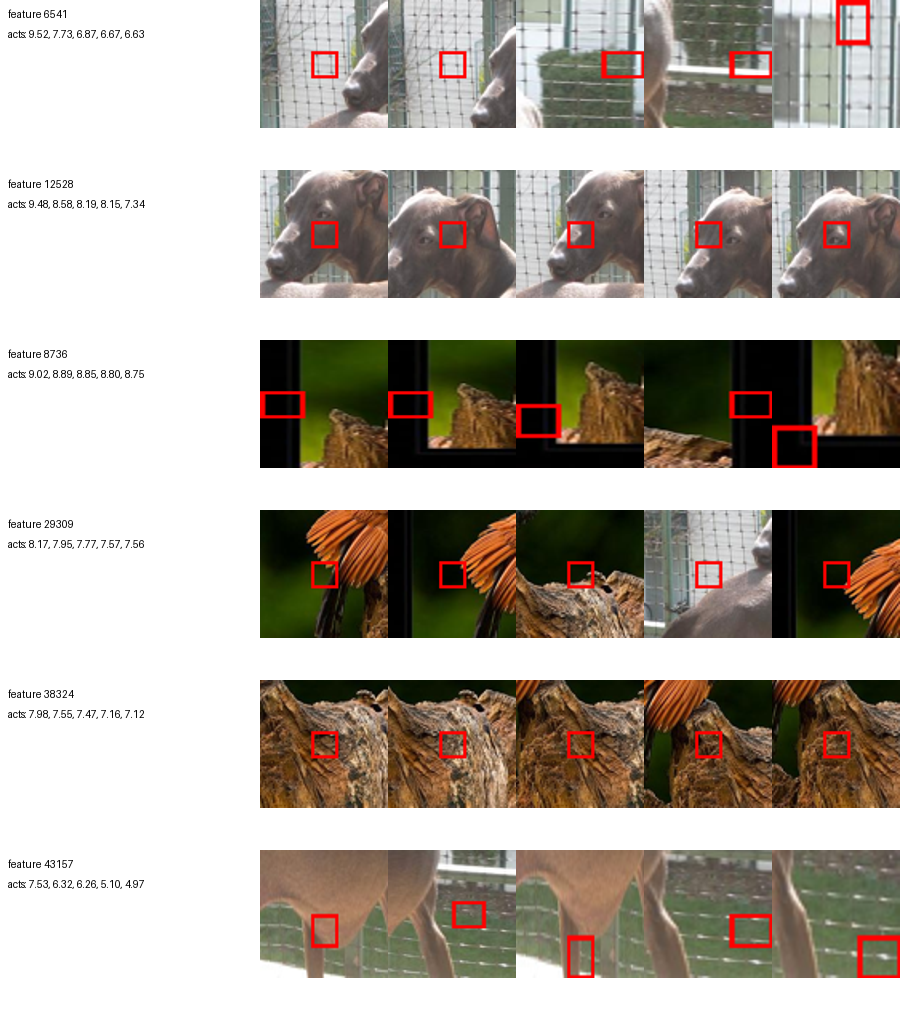

In [13]:
from src.features import get_top_patches_all_features

if RUN_ALL_FEATURES_SMOKE:
    all_feature_indices = list(range(min(ALL_FEATURE_IMAGE_COUNT, metadata["n_images"])))
    all_feature_paths = [str(image_path(index["paths"][i])) for i in all_feature_indices]
    all_feature_activations = load_layer(layer, indices=all_feature_indices, cachepath=cache_path)
    all_top_patches_smoke = get_top_patches_all_features(
        layer,
        all_feature_activations,
        all_feature_paths,
        k=TOP_K_PATCHES,
    )
    features_to_inspect = sorted(
        all_top_patches_smoke,
        key=lambda feature_idx: all_top_patches_smoke[feature_idx][0]["activation_value"],
        reverse=True,
    )[:N_FEATURES_TO_INSPECT]
    patches_for_labeling = {
        feature_idx: all_top_patches_smoke[feature_idx]
        for feature_idx in features_to_inspect
    }
else:
    all_top_patches_smoke = {}
    features_to_inspect = [FEATURE_IDX]
    patches_for_labeling = {FEATURE_IDX: top_patches}

print(f"All-feature smoke results: {len(all_top_patches_smoke)} features")
print(f"Features selected for inspection: {features_to_inspect}")
make_patch_grid(patches_for_labeling)


## 7. CLIP auto-labeling


2026-05-27 17:49:49 DEBUG:httpcore.connection: close.started
2026-05-27 17:49:49 DEBUG:httpcore.connection: close.complete
2026-05-27 17:49:49 DEBUG:httpcore.connection: close.started
2026-05-27 17:49:49 DEBUG:httpcore.connection: close.complete
2026-05-27 17:49:49 DEBUG:httpcore.connection: connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
2026-05-27 17:49:49 DEBUG:httpcore.connection: connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x11e7a56a0>
2026-05-27 17:49:49 DEBUG:httpcore.connection: start_tls.started ssl_context=<ssl.SSLContext object at 0x1683c34d0> server_hostname='huggingface.co' timeout=10
2026-05-27 17:49:49 DEBUG:httpcore.connection: start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x11e7a7e60>
2026-05-27 17:49:49 DEBUG:httpcore.http11: send_request_headers.started request=<Request [b'HEAD']>
2026-05-27 17:49:49 DEBUG:httpcore.http11: send_request_headers.comp

feature 6541: ['spot', 'background', 'leg']
feature 12528: ['eye', 'background', 'spot']
feature 8736: ['background', 'black', 'grass']
feature 29309: ['spot', 'background', 'beak']
feature 38324: ['background', 'spot', 'brown']
feature 43157: ['grass', 'background', 'spot']


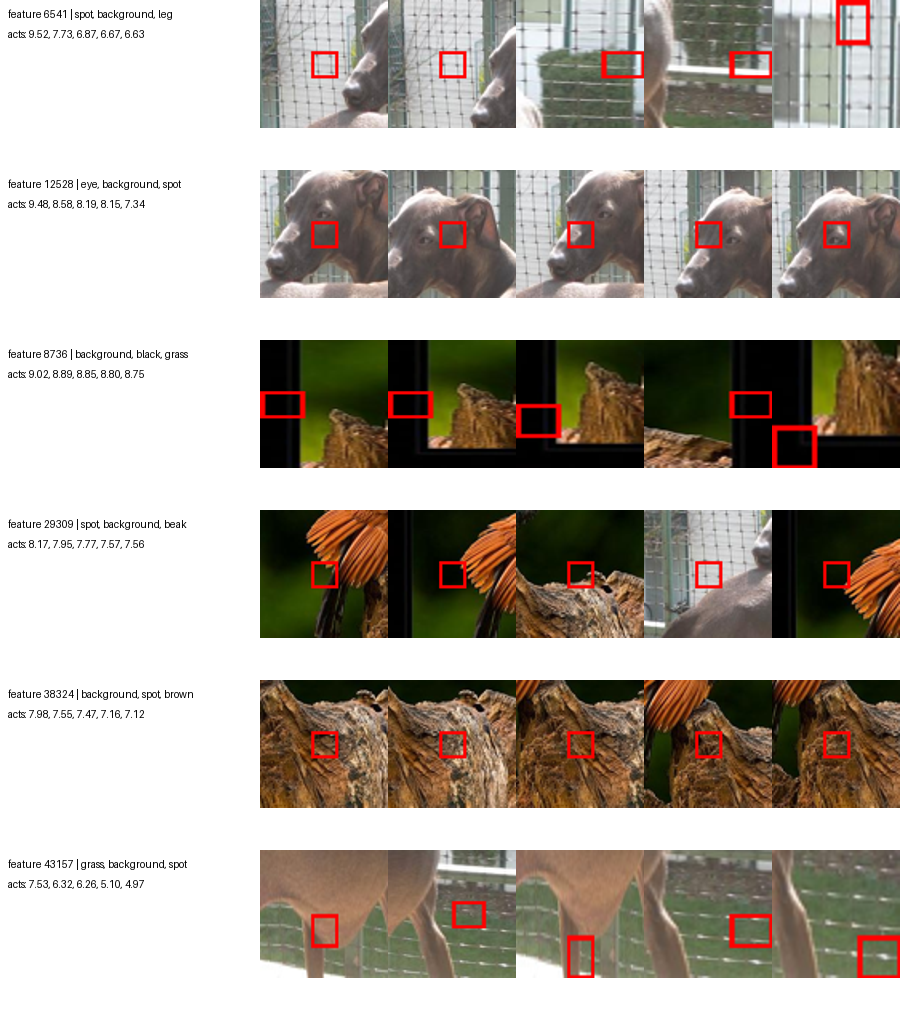

In [14]:
from src.features import load_clip_labeler, label_feature_clip

CONCEPT_VOCAB = [
    "bird", "beak", "wing", "feather", "eye", "head", "leg",
    "grass", "water", "sky", "tree", "branch", "leaf", "rock",
    "white", "pink", "black", "brown", "yellow", "red",
    "stripe", "spot", "edge", "texture", "background",
]

clip_model, processor = load_clip_labeler()
labels = {
    feature_idx: label_feature_clip(patches, CONCEPT_VOCAB, clip_model, processor, top_n=CLIP_TOP_N)
    for feature_idx, patches in patches_for_labeling.items()
}

for feature_idx, feature_labels in labels.items():
    print(f"feature {feature_idx}: {feature_labels}")

make_patch_grid(patches_for_labeling, labels=labels)


## 8. Week 2 placeholders

Monosemanticity scores, feature-gallery report figures, and top-50 manual annotation belong to Week 2. Keep those implementations in `src/features.py` and `src/visualise.py`, then call them here once they exist.

## Week 1 checkpoint
- [x] Activation cache loads
- [x] Layer 9 activations load for a local smoke slice
- [x] Single-feature top patches are retrieved from `src.features`
- [x] CLIP labels are produced from the same patch crops
- [ ] Manually inspect several feature rows: red boxes should focus on a consistent visual pattern, and CLIP labels should roughly match that pattern